In [1]:
%matplotlib inline
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
from tempfile import TemporaryDirectory
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
import xgboost as xgb
from xgboost import XGBClassifier
#from lightgbm import LGBMClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import seaborn as sns
import numpy as np
import warnings

c:\Users\abhin\.pyenv\pyenv-win\versions\3.14.2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
target_column = "health_condition"
df = pd.read_csv("data/train.csv")
model = joblib.load('models/xgboost_tts_80.pkl')

In [3]:
df['diet_type'] = df['diet_type'].astype('category')
df['stress_level'] = df['stress_level'].replace({'low':0, 'medium':1, 'high':2})
df['sleep_quality'] = df['sleep_quality'].replace({'poor':0, 'average':1, 'good':2})
df['physical_activity_level'] = df['physical_activity_level'].replace({'sedentary':0, 'moderate':1, 'active':2})
df['smoking_alcohol'] = df['smoking_alcohol'].replace({'no':0, 'occasional':1, 'yes':2})
df['gender'] = df['gender'].astype('category')

object_cols = ['stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol']
for col in object_cols:
    df[col] = df[col].astype('category')

df['has_exercised'] = df['exercise_duration'] > 0

df['calorie_expenditure_per_step'] = df['calorie_expenditure'] / (df['step_count']+1)
df['step_speed'] = df['step_count'] / (df['exercise_duration']+1)
df['calorie_expenditure_per_min'] = df['calorie_expenditure'] / (df['exercise_duration']+1)
df['calorie_expenditure_per_bmi'] = df['calorie_expenditure'] / (df['bmi']+1)

In [4]:
y = df[target_column].replace({'unhealthy':0, 'at-risk':1, 'fit':2}).astype('int')
X = df.drop(target_column, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Shap Tree Explainer**

In [5]:
explainer = shap.TreeExplainer(model)

In [6]:
shap_values = explainer(X_test)

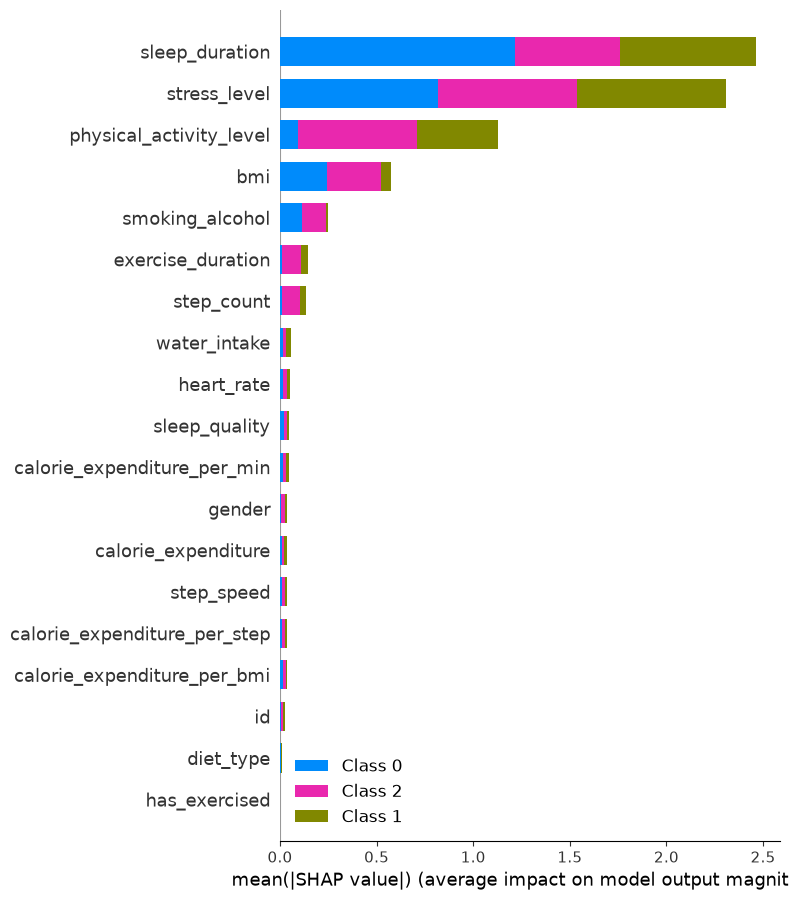

In [7]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

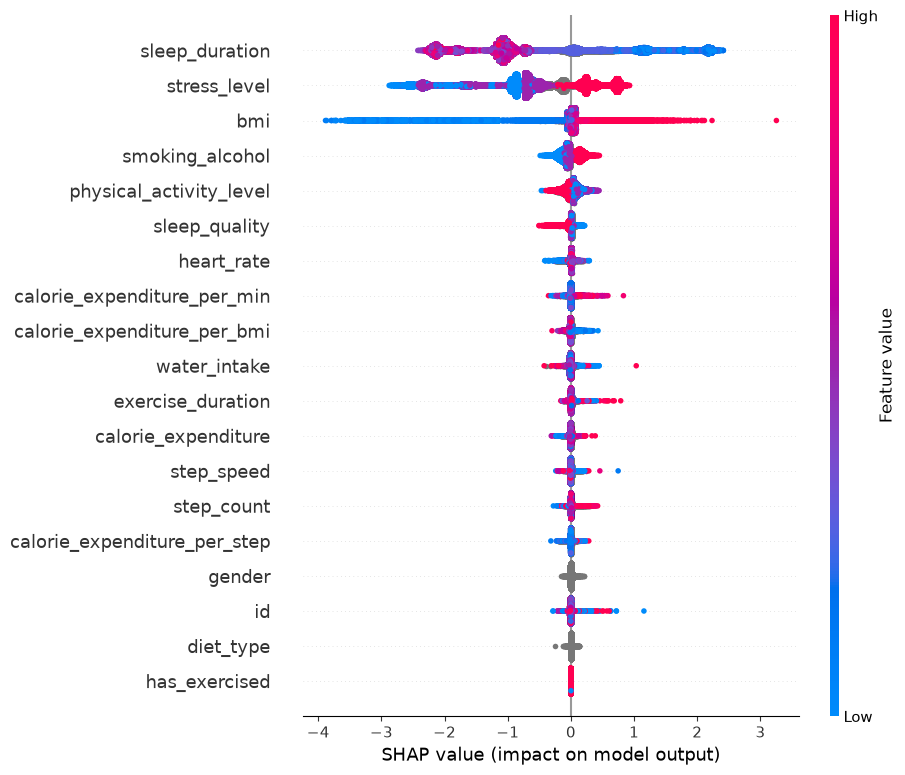

In [11]:
shap.plots.beeswarm(shap_values[:,:,0], max_display=20) # unhealthy class

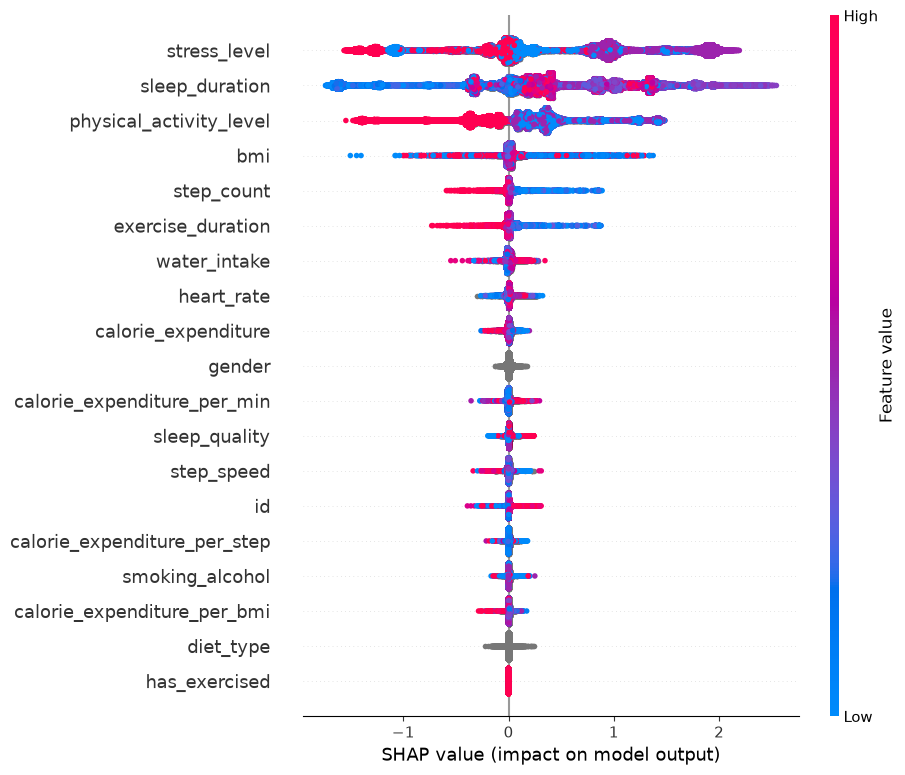

In [9]:
shap.plots.beeswarm(shap_values[:,:,1], max_display=20) # at-risk class

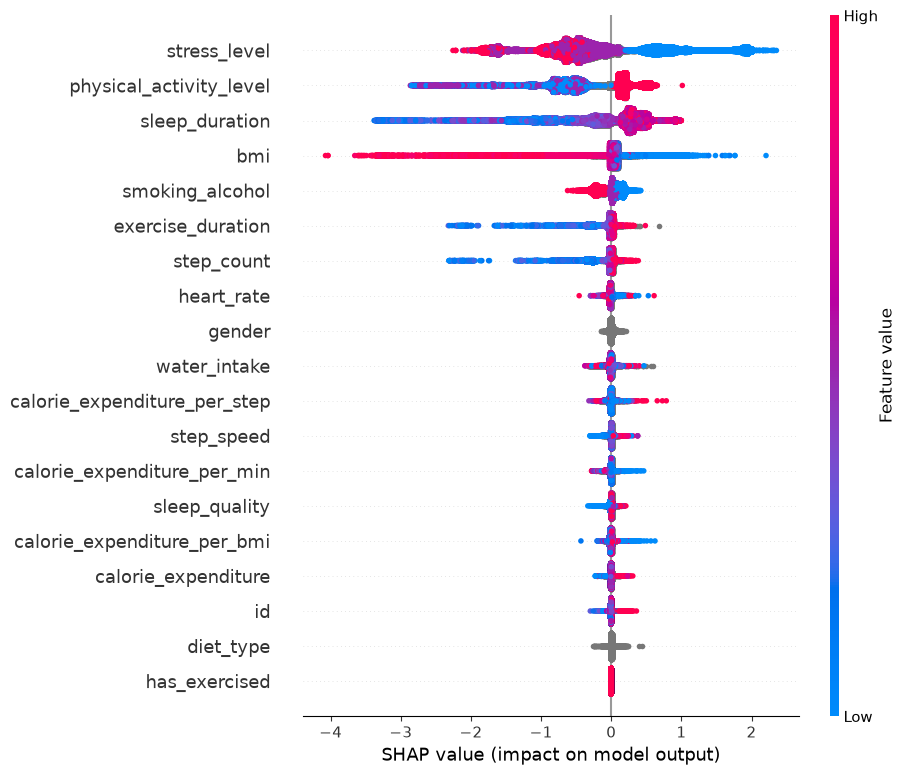

In [10]:
shap.plots.beeswarm(shap_values[:,:,2], max_display=20) # fit class